In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')
from imblearn.ensemble import BalancedRandomForestClassifier

Cargando datos...
Datos cargados: 3,495,160 registros
Extrayendo coordenadas por cluster...
Coordenadas extraídas para 100 clusters
Creando características...
Características creadas exitosamente
Datos de entrenamiento: 3,047,548 registros
Datos de prueba: 447,612 registros
Datos balanceados: 359,328 registros
Proporción de accidentes: 0.167

Entrenando RandomForest...
RandomForest - Train: 0.811, Test: 0.755, AUC: 0.811

Entrenando GradientBoosting...
GradientBoosting - Train: 0.869, Test: 0.941, AUC: 0.808

Entrenando LogisticRegression...
LogisticRegression - Train: 0.727, Test: 0.713, AUC: 0.794

Entrenando model_balanced...
model_balanced - Train: 0.765, Test: 0.701, AUC: 0.811

Mejor modelo: model_balanced
AUC Score: 0.811

REPORTE DETALLADO DEL MODELO

RandomForest:
  Train Accuracy: 0.811
  Test Accuracy: 0.755
  AUC Score: 0.811

Classification Report for RandomForest:
              precision    recall  f1-score   support

 No Accident       0.99      0.76      0.86    440076


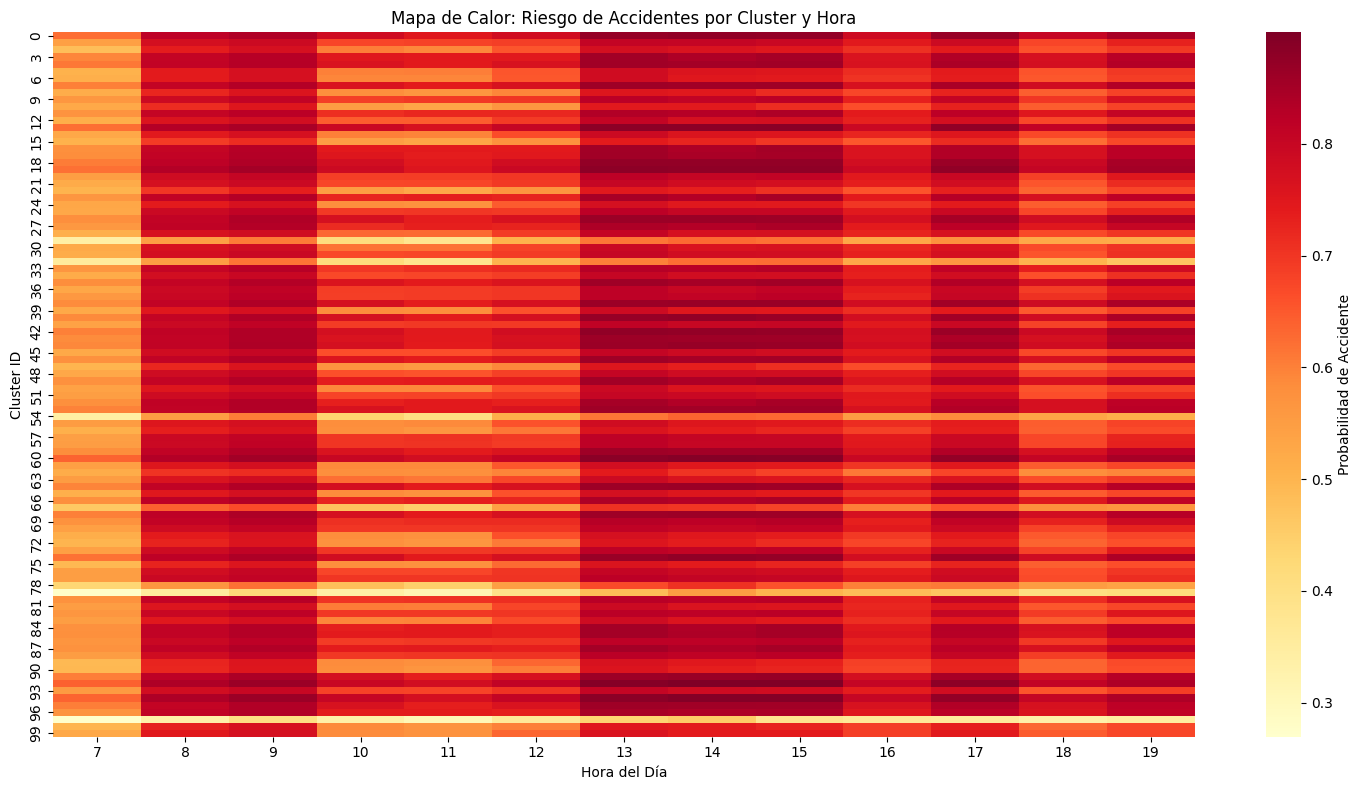


Predicciones guardadas en: predictions_2025-01-15.csv


: 

In [ ]:


class BarcelonaAccidentPredictor:
    def __init__(self, data_path=None):
        """
        Inicializar el predictor de accidentes
        
        Parameters:
        data_path (str): Ruta al archivo de datos
        """
        self.data_path = data_path
        self.df = None
        self.model = None
        self.scaler = StandardScaler()
        self.feature_columns = None
        self.cluster_coordinates = {}
        
    def load_data(self, file_path=None):
        """Cargar y procesar los datos"""
        if file_path:
            self.data_path = file_path
            
        print("Cargando datos...")
        try:
            # Cargar datos (ajustar separador según tu archivo)
            self.df = pd.read_csv(self.data_path, low_memory=False)
            print(f"Datos cargados: {len(self.df):,} registros")
            
            # Convertir columna de tiempo
            self.df['time_n'] = pd.to_datetime(self.df['time_n'])
            
            # Extraer coordenadas por cluster
            self._extract_cluster_coordinates()
            
            return True
            
        except Exception as e:
            print(f"Error al cargar datos: {e}")
            return False
    
    def _extract_cluster_coordinates(self):
        """Extraer coordenadas representativas por cluster"""
        print("Extrayendo coordenadas por cluster...")
        
        for cluster_id in self.df['cluster_id'].unique():
            if cluster_id != -1:  # Excluir outliers
                cluster_data = self.df[self.df['cluster_id'] == cluster_id]
                if not cluster_data.empty:
                    # Tomar una muestra representativa
                    sample_geom = cluster_data['geometry'].iloc[0]
                    try:
                        # Extraer coordenadas de POINT(lon lat)
                        coords = sample_geom.replace('POINT (', '').replace(')', '').split()
                        lon, lat = float(coords[0]), float(coords[1])
                        self.cluster_coordinates[cluster_id] = (lat, lon)
                    except:
                        continue
        
        print(f"Coordenadas extraídas para {len(self.cluster_coordinates)} clusters")
    
    def feature_engineering(self):
        """Crear características adicionales"""
        print("Creando características...")
        
        # Características temporales cíclicas
        self.df['hour_sin'] = np.sin(2 * np.pi * self.df['hour'] / 24)
        self.df['hour_cos'] = np.cos(2 * np.pi * self.df['hour'] / 24)
        self.df['day_sin'] = np.sin(2 * np.pi * self.df['day'] / 31)
        self.df['day_cos'] = np.cos(2 * np.pi * self.df['day'] / 31)
        self.df['month_sin'] = np.sin(2 * np.pi * self.df['month'] / 12)
        self.df['month_cos'] = np.cos(2 * np.pi * self.df['month'] / 12)
        self.df['day_of_week_sin'] = np.sin(2 * np.pi * self.df['day_of_week'] / 7)
        self.df['day_of_week_cos'] = np.cos(2 * np.pi * self.df['day_of_week'] / 7)
        
        # Características de interacción
        self.df['temp_wind'] = self.df['temperature_2m (°C)'] * self.df['wind_speed_10m (km/h)']
        self.df['temp_precip'] = self.df['temperature_2m (°C)'] * self.df['precipitation (mm)']
        self.df['weekend_night'] = self.df['is_weekend'] * (self.df['hour'].isin([22, 23, 0, 1, 2, 3])).astype(int)
        self.df['rush_hour'] = ((self.df['hour'].isin([7, 8, 9])) | (self.df['hour'].isin([17, 18, 19]))).astype(int)
        
        # Características estacionales
        self.df['is_summer'] = self.df['month'].isin([6, 7, 8]).astype(int)
        self.df['is_winter'] = self.df['month'].isin([12, 1, 2]).astype(int)
        
        # Características de cluster (agregaciones)
        cluster_stats = self.df.groupby('cluster_id')['accident'].agg(['mean', 'std']).reset_index()
        cluster_stats.columns = ['cluster_id', 'cluster_accident_rate', 'cluster_accident_std']
        cluster_stats['cluster_accident_std'] = cluster_stats['cluster_accident_std'].fillna(0)
        
        self.df = self.df.merge(cluster_stats, on='cluster_id', how='left')
        
        print("Características creadas exitosamente")
    
    def prepare_model_data(self):
        """Preparar datos para entrenamiento"""
        self.feature_columns = [
            'cluster_id', 'temperature_2m (°C)', 'precipitation (mm)', 
            'snowfall (cm)', 'wind_speed_10m (km/h)', 'Fiesta', 'dia_festivo',
            'month', 'day', 'hour', 'day_of_week', 'is_weekend',
            'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 
            'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos',
            'temp_wind', 'temp_precip', 'weekend_night', 'rush_hour',
            'is_summer', 'is_winter', 'cluster_accident_rate', 'cluster_accident_std'
        ]
        
        # Dividir por años
        self.train_data = self.df[self.df['year'] < 2024].copy()
        self.test_data = self.df[self.df['year'] == 2024].copy()
        
        print(f"Datos de entrenamiento: {len(self.train_data):,} registros")
        print(f"Datos de prueba: {len(self.test_data):,} registros")
        
        # Balancear clases en entrenamiento (submuestreo)
        accident_data = self.train_data[self.train_data['accident'] == 1]
        no_accident_data = self.train_data[self.train_data['accident'] == 0]
        
        # Tomar una muestra de no-accidentes
        no_accident_sample = no_accident_data.sample(n=min(len(accident_data)*5, len(no_accident_data)), 
                                                    random_state=42)
        
        self.train_data_balanced = pd.concat([accident_data, no_accident_sample]).sample(frac=1, random_state=42)
        
        print(f"Datos balanceados: {len(self.train_data_balanced):,} registros")
        print(f"Proporción de accidentes: {self.train_data_balanced['accident'].mean():.3f}")
    
    def train_models(self):
        """Entrenar múltiples modelos y seleccionar el mejor"""
        X_train = self.train_data_balanced[self.feature_columns]
        y_train = self.train_data_balanced['accident']
        X_test = self.test_data[self.feature_columns]
        y_test = self.test_data['accident']
        
        # Definir modelos
        models = {
            'RandomForest': RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42,
                class_weight='balanced',
                n_jobs=-1
            ),
            'GradientBoosting': GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=8,
                random_state=42
            ),
            'LogisticRegression': LogisticRegression(
                random_state=42,
                class_weight='balanced',
                max_iter=1000
            ),
            'model_balanced' : BalancedRandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1,
            sampling_strategy='auto'  # Balance automático
            )
        
        }
        
        results = {}
        
        for name, model in models.items():
            print(f"\nEntrenando {name}...")
            
            if name == 'LogisticRegression':
                # Escalar características para regresión logística
                X_train_scaled = self.scaler.fit_transform(X_train)
                X_test_scaled = self.scaler.transform(X_test)
                
                model.fit(X_train_scaled, y_train)
                train_score = model.score(X_train_scaled, y_train)
                test_score = model.score(X_test_scaled, y_test)
                y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
            else:
                model.fit(X_train, y_train)
                train_score = model.score(X_train, y_train)
                test_score = model.score(X_test, y_test)
                y_pred_proba = model.predict_proba(X_test)[:, 1]
            
            auc_score = roc_auc_score(y_test, y_pred_proba)
            
            results[name] = {
                'model': model,
                'train_score': train_score,
                'test_score': test_score,
                'auc_score': auc_score,
                'predictions': y_pred_proba
            }
            
            print(f"{name} - Train: {train_score:.3f}, Test: {test_score:.3f}, AUC: {auc_score:.3f}")
        
        # Seleccionar mejor modelo basado en AUC
        best_model_name = max(results.keys(), key=lambda k: results[k]['auc_score'])
        self.model = results[best_model_name]['model']
        self.best_model_name = best_model_name
        
        print(f"\nMejor modelo: {best_model_name}")
        print(f"AUC Score: {results[best_model_name]['auc_score']:.3f}")
        
        # Generar reporte detallado
        self._generate_model_report(X_test, y_test, results)
        
        return results
    
    def _generate_model_report(self, X_test, y_test, results):
        """Generar reporte detallado del modelo"""
        print("\n" + "="*50)
        print("REPORTE DETALLADO DEL MODELO")
        print("="*50)
        
        for name, result in results.items():
            print(f"\n{name}:")
            print(f"  Train Accuracy: {result['train_score']:.3f}")
            print(f"  Test Accuracy: {result['test_score']:.3f}")
            print(f"  AUC Score: {result['auc_score']:.3f}")
            
            # Predicciones binarias
            y_pred = (result['predictions'] > 0.5).astype(int)
            
            print(f"\nClassification Report for {name}:")
            print(classification_report(y_test, y_pred, target_names=['No Accident', 'Accident']))
    
    def get_feature_importance(self):
        """Obtener importancia de características"""
        if self.model is None:
            print("Modelo no entrenado")
            return None
        
        if hasattr(self.model, 'feature_importances_'):
            importance_df = pd.DataFrame({
                'feature': self.feature_columns,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            print("\nTop 10 características más importantes:")
            print(importance_df.head(10))
            
            return importance_df
        else:
            print("El modelo no proporciona importancia de características")
            return None
    
    def predict_accidents(self, date, hour_start, hour_end, weather_data=None):
        """
        Predecir accidentes para una fecha y rango de horas específico
        
        Parameters:
        date: datetime.date - fecha de predicción
        hour_start: int - hora de inicio
        hour_end: int - hora de fin
        weather_data: dict - datos meteorológicos (opcional)
        
        Returns:
        pandas.DataFrame - predicciones por cluster y hora
        """
        if self.model is None:
            print("Modelo no entrenado")
            return None
        
        predictions = []
        
        # Generar datos meteorológicos si no se proporcionan
        if weather_data is None:
            weather_data = self._generate_weather_forecast(date, hour_start, hour_end)
        
        for hour in range(hour_start, hour_end + 1):
            for cluster_id in self.cluster_coordinates.keys():
                # Obtener datos meteorológicos para esta hora
                hour_weather = weather_data.get(hour, {})
                
                # Crear características
                features = self._create_prediction_features(
                    cluster_id=cluster_id,
                    date=date,
                    hour=hour,
                    weather=hour_weather
                )
                
                # Realizar predicción
                if self.best_model_name == 'LogisticRegression':
                    features_scaled = self.scaler.transform([features])
                    prob = self.model.predict_proba(features_scaled)[0][1]
                else:
                    prob = self.model.predict_proba([features])[0][1]
                
                # Obtener coordenadas
                lat, lon = self.cluster_coordinates[cluster_id]
                
                predictions.append({
                    'cluster_id': cluster_id,
                    'hour': hour,
                    'date': date,
                    'latitude': lat,
                    'longitude': lon,
                    'accident_probability': prob,
                    'risk_level': self._categorize_risk(prob),
                    **hour_weather
                })
        
        return pd.DataFrame(predictions)
    
    def _create_prediction_features(self, cluster_id, date, hour, weather):
        """Crear vector de características para predicción"""
        is_weekend = int(date.weekday() >= 5)
        day_of_week = date.weekday()
        
        # Obtener estadísticas históricas del cluster
        cluster_rate = 0.1  # Default
        cluster_std = 0.1   # Default
        
        if hasattr(self, 'df') and self.df is not None:
            cluster_data = self.df[self.df['cluster_id'] == cluster_id]
            if not cluster_data.empty:
                cluster_rate = cluster_data['accident'].mean()
                cluster_std = cluster_data['accident'].std()
                if pd.isna(cluster_std):
                    cluster_std = 0.1
        
        features = [
            cluster_id,
            weather.get('temperature', 15.0),
            weather.get('precipitation', 0.0),
            weather.get('snowfall', 0.0),
            weather.get('wind_speed', 10.0),
            0,  # Fiesta
            0,  # dia_festivo
            date.month,
            date.day,
            hour,
            day_of_week,
            is_weekend,
            np.sin(2 * np.pi * hour / 24),  # hour_sin
            np.cos(2 * np.pi * hour / 24),  # hour_cos
            np.sin(2 * np.pi * date.day / 31),  # day_sin
            np.cos(2 * np.pi * date.day / 31),  # day_cos
            np.sin(2 * np.pi * date.month / 12),  # month_sin
            np.cos(2 * np.pi * date.month / 12),  # month_cos
            np.sin(2 * np.pi * day_of_week / 7),  # day_of_week_sin
            np.cos(2 * np.pi * day_of_week / 7),  # day_of_week_cos
            weather.get('temperature', 15.0) * weather.get('wind_speed', 10.0),  # temp_wind
            weather.get('temperature', 15.0) * weather.get('precipitation', 0.0),  # temp_precip
            is_weekend * int(hour in [22, 23, 0, 1, 2, 3]),  # weekend_night
            int(hour in [7, 8, 9, 17, 18, 19]),  # rush_hour
            int(date.month in [6, 7, 8]),  # is_summer
            int(date.month in [12, 1, 2]),  # is_winter
            cluster_rate,  # cluster_accident_rate
            cluster_std   # cluster_accident_std
        ]
        
        return features
    
    def _generate_weather_forecast(self, date, hour_start, hour_end):
        """Generar pronóstico meteorológico simulado"""
        weather_data = {}
        
        # Temperaturas base por mes para Barcelona
        temp_base = {1: 10, 2: 12, 3: 15, 4: 17, 5: 21, 6: 25,
                     7: 28, 8: 28, 9: 24, 10: 19, 11: 14, 12: 11}
        
        base_temp = temp_base.get(date.month, 15)
        
        for hour in range(hour_start, hour_end + 1):
            # Variación diurna de temperatura
            hour_temp_adj = np.sin(2 * np.pi * (hour - 6) / 24) * 5
            temperature = base_temp + hour_temp_adj + np.random.normal(0, 2)
            
            # Precipitación (más probable en invierno y por la tarde/noche)
            precip_prob = 0.1
            if date.month in [10, 11, 12, 1, 2, 3]:
                precip_prob = 0.2
            if hour >= 15:
                precip_prob *= 1.5
            
            precipitation = np.random.exponential(0.5) if np.random.random() < precip_prob else 0.0
            
            # Nieve (solo en invierno y temperaturas bajas)
            snowfall = 0.0
            if date.month in [12, 1, 2] and temperature < 5:
                snowfall = max(0, np.random.exponential(0.2)) if precipitation > 0 else 0.0
            
            # Viento
            wind_speed = max(0, np.random.normal(15, 8))
            
            weather_data[hour] = {
                'temperature': temperature,
                'precipitation': precipitation,
                'snowfall': snowfall,
                'wind_speed': wind_speed
            }
        
        return weather_data
    
    def _categorize_risk(self, probability):
        """Categorizar nivel de riesgo"""
        if probability >= 0.7:
            return 'Alto'
        elif probability >= 0.5:
            return 'Medio'
        elif probability >= 0.3:
            return 'Bajo'
        else:
            return 'Muy Bajo'
    
    def save_model(self, filepath):
        """Guardar modelo entrenado"""
        model_data = {
            'model': self.model,
            'scaler': self.scaler,
            'feature_columns': self.feature_columns,
            'cluster_coordinates': self.cluster_coordinates,
            'best_model_name': self.best_model_name
        }
        
        joblib.dump(model_data, filepath)
        print(f"Modelo guardado en: {filepath}")
    
    def load_model(self, filepath):
        """Cargar modelo previamente entrenado"""
        model_data = joblib.load(filepath)
        
        self.model = model_data['model']
        self.scaler = model_data['scaler']
        self.feature_columns = model_data['feature_columns']
        self.cluster_coordinates = model_data['cluster_coordinates']
        self.best_model_name = model_data['best_model_name']
        
        print(f"Modelo cargado desde: {filepath}")
    
    def plot_risk_heatmap(self, predictions_df):
        """Crear mapa de calor de riesgo por hora y cluster"""
        if predictions_df.empty:
            return
        
        plt.figure(figsize=(15, 8))
        
        # Crear matriz de riesgo
        risk_matrix = predictions_df.pivot_table(
            values='accident_probability',
            index='cluster_id',
            columns='hour',
            fill_value=0
        )
        
        sns.heatmap(
            risk_matrix,
            cmap='YlOrRd',
            cbar_kws={'label': 'Probabilidad de Accidente'},
            fmt='.2f'
        )
        
        plt.title('Mapa de Calor: Riesgo de Accidentes por Cluster y Hora')
        plt.xlabel('Hora del Día')
        plt.ylabel('Cluster ID')
        plt.tight_layout()
        plt.show()
    
    def generate_risk_summary(self, predictions_df):
        """Generar resumen de riesgo"""
        if predictions_df.empty:
            return
        
        print("\n" + "="*50)
        print("RESUMEN DE RIESGO DE ACCIDENTES")
        print("="*50)
        
        # Estadísticas generales
        total_predictions = len(predictions_df)
        high_risk = len(predictions_df[predictions_df['risk_level'] == 'Alto'])
        medium_risk = len(predictions_df[predictions_df['risk_level'] == 'Medio'])
        
        print(f"Total de predicciones: {total_predictions}")
        print(f"Ubicaciones de alto riesgo: {high_risk} ({high_risk/total_predictions*100:.1f}%)")
        print(f"Ubicaciones de riesgo medio: {medium_risk} ({medium_risk/total_predictions*100:.1f}%)")
        
        # Top 10 ubicaciones de mayor riesgo
        top_risk = predictions_df.nlargest(10, 'accident_probability')
        print(f"\nTop 10 ubicaciones de mayor riesgo:")
        print(top_risk[['cluster_id', 'hour', 'accident_probability', 'risk_level']].to_string(index=False))
        
        # Riesgo por hora
        hourly_risk = predictions_df.groupby('hour')['accident_probability'].mean().sort_values(ascending=False)
        print(f"\nRiesgo promedio por hora:")
        for hour, risk in hourly_risk.head(5).items():
            print(f"  {hour:02d}:00 - {risk:.3f}")


# Función principal para ejecutar el pipeline completo
def main():
    """Ejecutar pipeline completo de entrenamiento y predicción"""
    
    # Inicializar predictor
    predictor = BarcelonaAccidentPredictor()
    
    # Cargar datos (ajustar ruta según tu archivo)
    data_path = "../data/processed/df_ready_model.csv"  # Cambiar por tu archivo completo
    
    if predictor.load_data(data_path):
        # Ingeniería de características
        predictor.feature_engineering()
        
        # Preparar datos para el modelo
        predictor.prepare_model_data()
        
        # Entrenar modelos
        results = predictor.train_models()
        
        # Mostrar importancia de características
        importance = predictor.get_feature_importance()
        
        # Guardar modelo
        predictor.save_model('barcelona_accident_model.pkl')
        
        # Ejemplo de predicción
        from datetime import datetime, date
        
        prediction_date = date(2025, 1, 15)  # Cambiar fecha
        predictions = predictor.predict_accidents(
            date=prediction_date,
            hour_start=7,
            hour_end=19
        )
        
        if predictions is not None:
            # Mostrar resumen
            predictor.generate_risk_summary(predictions)
            
            # Crear mapa de calor
            predictor.plot_risk_heatmap(predictions)
            
            # Guardar predicciones
            predictions.to_csv(f'predictions_{prediction_date}.csv', index=False)
            print(f"\nPredicciones guardadas en: predictions_{prediction_date}.csv")
    
    return predictor


if __name__ == "__main__":
    # Ejecutar pipeline principal
    predictor = main()